In [1]:
# RNA Secondary Structure Prediction
# Dynamic Programming Approach

import numpy as np
import matplotlib.pyplot as plt

# Example RNA sequence
rna_sequence = "GGGAAAUCC"

# Valid RNA base pairs
base_pairs = {
    "A": "U",
    "U": "A",
    "G": "C",
    "C": "G"
}

print("RNA Sequence:", rna_sequence)
print("Sequence Length:", len(rna_sequence))

RNA Sequence: GGGAAAUCC
Sequence Length: 9


In [2]:
# Initialize dynamic programming matrix
n = len(rna_sequence)
dp = np.zeros((n, n), dtype=int)

print("DP Matrix Shape:", dp.shape)
print(dp)

DP Matrix Shape: (9, 9)
[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


In [3]:
# Check whether two RNA bases can form a valid pair

def can_pair(base1, base2):
    return (
        (base1 == "A" and base2 == "U") or
        (base1 == "U" and base2 == "A") or
        (base1 == "G" and base2 == "C") or
        (base1 == "C" and base2 == "G")
    )

# Test valid and invalid pairs
print("A-U:", can_pair("A", "U"))
print("G-C:", can_pair("G", "C"))
print("A-G:", can_pair("A", "G"))

A-U: True
G-C: True
A-G: False


In [4]:
# Fill the DP matrix using dynamic programming

for length in range(2, n + 1):
    for i in range(n - length + 1):
        j = i + length - 1

        # Option 1: leave base i unpaired
        dp[i, j] = dp[i + 1, j]

        # Option 2: leave base j unpaired
        dp[i, j] = max(dp[i, j], dp[i, j - 1])

        # Option 3: pair bases i and j
        if can_pair(rna_sequence[i], rna_sequence[j]):
            dp[i, j] = max(dp[i, j], dp[i + 1, j - 1] + 1)

print("Final DP Matrix:")
print(dp)

Final DP Matrix:
[[0 0 0 0 0 0 1 2 3]
 [0 0 0 0 0 0 1 2 3]
 [0 0 0 0 0 0 1 2 2]
 [0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


In [5]:
# Traceback to identify the optimal RNA base pairs

pairs = []
i, j = 0, n - 1

while i < j:
    if dp[i, j] == dp[i + 1, j]:
        i += 1
    elif dp[i, j] == dp[i, j - 1]:
        j -= 1
    elif can_pair(rna_sequence[i], rna_sequence[j]) and \
         dp[i, j] == dp[i + 1, j - 1] + 1:
        pairs.append((i, j))
        i += 1
        j -= 1
    else:
        i += 1

print("Optimal Base Pairs:")
for i, j in pairs:
    print(f"{i+1}-{j+1}: {rna_sequence[i]}-{rna_sequence[j]}")

Optimal Base Pairs:
2-9: G-C
3-8: G-C
6-7: A-U


In [6]:
# Generate dot-bracket notation for the predicted structure

structure = ["."] * n

for i, j in pairs:
    structure[i] = "("
    structure[j] = ")"

dot_bracket = "".join(structure)

print("RNA Sequence:     ", rna_sequence)
print("Predicted Structure:", dot_bracket)
print("Number of Base Pairs:", len(pairs))

RNA Sequence:      GGGAAAUCC
Predicted Structure: .((..()))
Number of Base Pairs: 3


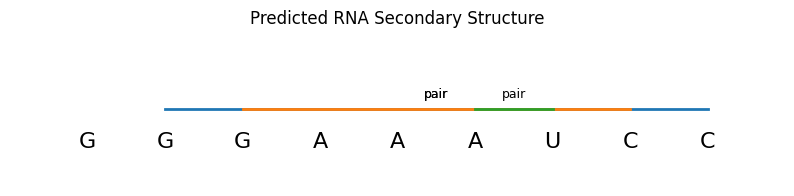

In [7]:
# Visualize the predicted RNA secondary structure

plt.figure(figsize=(10, 2))

for i, base in enumerate(rna_sequence):
    plt.text(i, 0, base, ha="center", va="center", fontsize=16)

for i, j in pairs:
    plt.plot([i, j], [0.15, 0.15], linewidth=2)
    plt.text((i + j) / 2, 0.2, "pair", ha="center", fontsize=9)

plt.xlim(-1, n)
plt.ylim(-0.2, 0.5)
plt.axis("off")
plt.title("Predicted RNA Secondary Structure")
plt.show()

In [9]:
# Summarize the prediction

print("RNA Secondary Structure Prediction Summary")
print("------------------------------------------")
print("Sequence:", rna_sequence)
print("Sequence Length:", n)
print("Predicted Structure:", dot_bracket)
print("Optimal Base Pairs:", len(pairs))
print("Base Pairs:", [(rna_sequence[i], rna_sequence[j]) for i, j in pairs])

RNA Secondary Structure Prediction Summary
------------------------------------------
Sequence: GGGAAAUCC
Sequence Length: 9
Predicted Structure: .((..()))
Optimal Base Pairs: 3
Base Pairs: [('G', 'C'), ('G', 'C'), ('A', 'U')]


In [10]:
# Test the algorithm with another RNA sequence

rna_sequence = "GCGAAAUCGC"
n = len(rna_sequence)

# Reinitialize DP matrix
dp = np.zeros((n, n), dtype=int)

# Fill DP matrix
for length in range(2, n + 1):
    for i in range(n - length + 1):
        j = i + length - 1

        dp[i, j] = dp[i + 1, j]
        dp[i, j] = max(dp[i, j], dp[i, j - 1])

        if can_pair(rna_sequence[i], rna_sequence[j]):
            dp[i, j] = max(dp[i, j], dp[i + 1, j - 1] + 1)

# Traceback
pairs = []
i, j = 0, n - 1

while i < j:
    if dp[i, j] == dp[i + 1, j]:
        i += 1
    elif dp[i, j] == dp[i, j - 1]:
        j -= 1
    elif can_pair(rna_sequence[i], rna_sequence[j]) and \
         dp[i, j] == dp[i + 1, j - 1] + 1:
        pairs.append((i, j))
        i += 1
        j -= 1
    else:
        i += 1

structure = ["."] * n

for i, j in pairs:
    structure[i] = "("
    structure[j] = ")"

dot_bracket = "".join(structure)

print("Test Sequence:", rna_sequence)
print("Predicted Structure:", dot_bracket)
print("Optimal Base Pairs:", len(pairs))

Test Sequence: GCGAAAUCGC
Predicted Structure: (((..())))
Optimal Base Pairs: 4


In [11]:
# Reusable RNA secondary structure prediction function

def predict_rna_structure(sequence):
    sequence = sequence.upper()
    n = len(sequence)
    dp = np.zeros((n, n), dtype=int)

    # Dynamic programming
    for length in range(2, n + 1):
        for i in range(n - length + 1):
            j = i + length - 1

            dp[i, j] = dp[i + 1, j]
            dp[i, j] = max(dp[i, j], dp[i, j - 1])

            if can_pair(sequence[i], sequence[j]):
                dp[i, j] = max(dp[i, j], dp[i + 1, j - 1] + 1)

    # Traceback
    pairs = []
    i, j = 0, n - 1

    while i < j:
        if dp[i, j] == dp[i + 1, j]:
            i += 1
        elif dp[i, j] == dp[i, j - 1]:
            j -= 1
        elif can_pair(sequence[i], sequence[j]) and \
             dp[i, j] == dp[i + 1, j - 1] + 1:
            pairs.append((i, j))
            i += 1
            j -= 1
        else:
            i += 1

    structure = ["."] * n

    for i, j in pairs:
        structure[i] = "("
        structure[j] = ")"

    return sequence, "".join(structure), pairs


# Test the reusable function
sequence, structure, pairs = predict_rna_structure("GCGAAAUCGC")

print("Sequence:", sequence)
print("Predicted Structure:", structure)
print("Base Pairs:", len(pairs))

Sequence: GCGAAAUCGC
Predicted Structure: (((..())))
Base Pairs: 4


In [12]:
# Predict secondary structure for a custom RNA sequence

user_sequence = input("Enter an RNA sequence (A, U, G, C): ")

sequence, structure, pairs = predict_rna_structure(user_sequence)

print("\nRNA Sequence:", sequence)
print("Predicted Structure:", structure)
print("Number of Base Pairs:", len(pairs))

Enter an RNA sequence (A, U, G, C): GGGAAAUCC

RNA Sequence: GGGAAAUCC
Predicted Structure: .((..()))
Number of Base Pairs: 3


In [13]:
# Test multiple RNA sequences

test_sequences = [
    "GGGAAAUCC",
    "GCGAAAUCGC",
    "AUGCGUACG"
]

for seq in test_sequences:
    sequence, structure, pairs = predict_rna_structure(seq)

    print("Sequence:", sequence)
    print("Structure:", structure)
    print("Base Pairs:", len(pairs))
    print("-" * 40)

Sequence: GGGAAAUCC
Structure: .((..()))
Base Pairs: 3
----------------------------------------
Sequence: GCGAAAUCGC
Structure: (((..())))
Base Pairs: 4
----------------------------------------
Sequence: AUGCGUACG
Structure: ...((()))
Base Pairs: 3
----------------------------------------
